---
title: "Lecture 2 – Logistic Regression & Classification"
subtitle: "ML – Missing Semester CUET"
format:
  html:
    code-fold: false
---

## Why Not Linear Regression for Classification?

If the target is binary ($y \in \{0, 1\}$), linear regression can predict values outside $[0, 1]$.

We need a function that **squashes** outputs into a probability range.

**Solution →** the **sigmoid** (logistic) function.

---

## The Sigmoid Function

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Properties:

- $\sigma(0) = 0.5$
- $\lim_{z \to \infty} \sigma(z) = 1$, $\lim_{z \to -\infty} \sigma(z) = 0$
- Derivative: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$

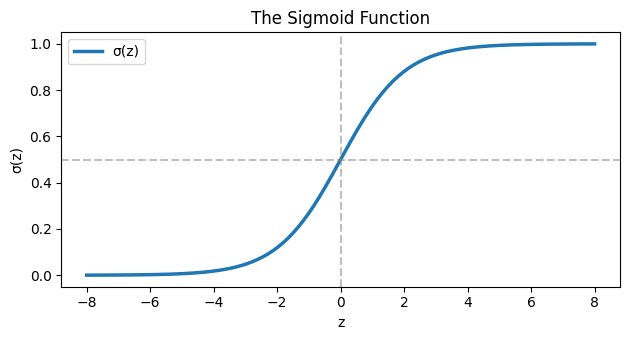

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-8, 8, 200)
plt.figure(figsize=(6.4, 3.5))
plt.plot(z, sigmoid(z), linewidth=2.5, label='σ(z)')
plt.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('z'); plt.ylabel('σ(z)')
plt.title('The Sigmoid Function')
plt.legend(); plt.tight_layout(); plt.show()

---

## Binary Cross-Entropy Loss

We can't use MSE — it creates a non-convex surface with sigmoid.

Instead, we use **log-loss** (binary cross-entropy):

$$J(\theta) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log(h_\theta(x^{(i)})) + (1-y^{(i)})\log(1-h_\theta(x^{(i)}))\right]$$

- When $y=1$: cost is $-\log(h)$ → penalises low predictions.
- When $y=0$: cost is $-\log(1-h)$ → penalises high predictions.

Training accuracy: 98.0%


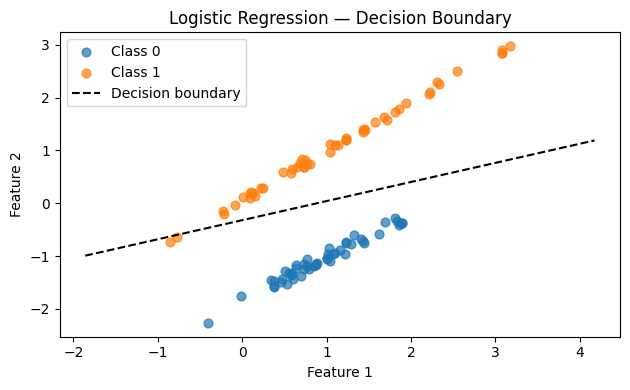

In [2]:
from sklearn.datasets import make_classification

# Generate a 2-class dataset
np.random.seed(42)
X, y = make_classification(n_samples=100, n_features=2, n_redundant=0,
                           n_clusters_per_class=1, random_state=42)
y = y.reshape(-1, 1)
X_b = np.c_[np.ones((100, 1)), X]

# Logistic regression from scratch
theta = np.zeros((3, 1))
alpha, epochs = 0.1, 300
m = len(X_b)

for _ in range(epochs):
    h = sigmoid(X_b @ theta)
    gradient = (1/m) * X_b.T @ (h - y)
    theta -= alpha * gradient

preds = (sigmoid(X_b @ theta) >= 0.5).astype(int)
accuracy = np.mean(preds == y)
print(f"Training accuracy: {accuracy*100:.1f}%")

# Decision boundary
plt.figure(figsize=(6.4, 4))
plt.scatter(X[y.ravel()==0, 0], X[y.ravel()==0, 1], label='Class 0', alpha=0.7, s=40)
plt.scatter(X[y.ravel()==1, 0], X[y.ravel()==1, 1], label='Class 1', alpha=0.7, s=40)
x_boundary = np.linspace(X[:,0].min()-1, X[:,0].max()+1, 100)
y_boundary = -(theta[0] + theta[1]*x_boundary) / theta[2]
plt.plot(x_boundary, y_boundary, 'k--', linewidth=1.5, label='Decision boundary')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('Logistic Regression — Decision Boundary')
plt.legend(); plt.tight_layout(); plt.show()

---

## Evaluation Metrics

| Metric | What it measures |
|--------|------------------|
| **Accuracy** | Overall correct predictions |
| **Precision** | Of predicted positives, how many are correct? |
| **Recall** | Of actual positives, how many did we find? |
| **F1-Score** | Harmonic mean of precision & recall |

Use the **confusion matrix** to visualise all four outcomes (TP, FP, TN, FN).

---

## Key Takeaways

1. Sigmoid squashes linear outputs into $[0, 1]$ → probabilities.
2. Binary cross-entropy is the correct loss for classification.
3. The decision boundary is a hyperplane in feature space.
4. Always look beyond accuracy — use precision, recall, and F1.

**Next up →** Neural Networks